In [2]:
import pandas as pd
import numpy as np

In [3]:
orders = pd.read_csv(r'D:\Brazzilian\01_Raw_Data\olist_orders_dataset.csv')
order_items  = pd.read_csv(r'D:\Brazzilian\01_Raw_Data\olist_order_items_dataset.csv')
products  = pd.read_csv(r'D:\Brazzilian\01_Raw_Data\olist_products_dataset.csv')
customers = pd.read_csv(r'D:\Brazzilian\01_Raw_Data\olist_customers_dataset.csv')
product_category_name_translation  = pd.read_csv(r'D:\Brazzilian\01_Raw_Data\product_category_name_translation.csv')

In [4]:
order_items[' price '] = (
    order_items[' price ']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

order_items['freight_value'] = (
    order_items['freight_value']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

In [5]:
timestamp_cols = ['order_purchase_timestamp', 'order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']

for col in timestamp_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce', format='%d/%m/%Y %H:%M')

print(orders[timestamp_cols].dtypes)

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


In [6]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], format='%d/%m/%Y %H:%M')

In [7]:
revenue_cols = [' price ', 'freight_value']

for cols in revenue_cols:
    order_items[cols] = pd.to_numeric(order_items[cols], errors='coerce').fillna(0).astype(float)

print(order_items[revenue_cols].dtypes)

 price           float64
freight_value    float64
dtype: object


In [8]:

order_value = order_items.groupby('order_id')[' price '].sum() + order_items.groupby('order_id')['freight_value'].sum()


In [9]:
mean_order_value = order_value.mean()
median_order_value = order_value.median()
std_order_value = order_value.std()

In [10]:
print(f"Mean (Average) Order Value: {mean_order_value:.2f}")
print(f"Median Order Value:         {median_order_value:.2f}")
print(f"Standard Deviation:         {std_order_value:.2f}")

Mean (Average) Order Value: 160.58
Median Order Value:         105.29
Standard Deviation:         220.47


In [11]:
order_items.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 ' price ',
 'freight_value']

In [12]:
order_items[order_items['order_id'] == order_items['order_id'].iloc[0]]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:00,58.9,13.29


In [13]:
order_value.describe()

count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
dtype: float64

In [14]:
order_items[' price '].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name:  price , dtype: float64

In [15]:
order_items[' price '].head(10)

0     58.90
1    239.90
2    199.00
3     12.99
4    199.90
5     21.90
6     19.90
7    810.00
8    145.95
9     53.99
Name:  price , dtype: float64

In [16]:
merged = orders.merge(customers, on='customer_id')
merged = merged.merge(order_items, on='order_id')
merged = merged.merge(products, on='product_id')
merged = merged.merge(product_category_name_translation, on='product_category_name')

In [17]:
total_revenue = merged.groupby('customer_unique_id')[' price '].sum() + merged.groupby('customer_unique_id')['freight_value'].sum()

In [18]:
total_revenue

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2     141.90
0000b849f77a49e4a4ce2b2a4ca5be3f      27.19
0000f46a3911fa3c0805444483337064      86.22
0000f6ccb0745a6a4b88665a16c9f078      43.62
0004aac84e0df4da2b147fca70cf8255     196.89
                                     ...   
fffcf5a5ff07b0908bd4e2dbc735a684    2067.42
fffea47cd6d3cc0a88bd621562a9d061      84.58
ffff371b4d645b6ecea244b27531430a     112.46
ffff5962728ec6157033ef9805bacc48     133.69
ffffd2657e2aad2907e67c3e9daecbeb      71.56
Length: 94088, dtype: float64

In [19]:
customer_spend = total_revenue.reset_index()
customer_spend.columns = ['customer_unique_id', 'total_spend']

In [20]:
spend_bins = [0, 300, 1000, np.inf]

In [21]:
spend_labels = ['Low Spend (< 300)', 'Medium Spend (300-1000)', 'High Spend (> 1000)']

In [22]:
customer_spend['spend_tier'] = pd.cut(
    customer_spend['total_spend'], 
    bins=spend_bins, 
    labels=spend_labels,
    right=False)

In [23]:
print(customer_spend['spend_tier'].value_counts())

spend_tier
Low Spend (< 300)          83536
Medium Spend (300-1000)     9382
High Spend (> 1000)         1170
Name: count, dtype: int64


# Matplotlib

In [24]:
import matplotlib.pyplot as plt

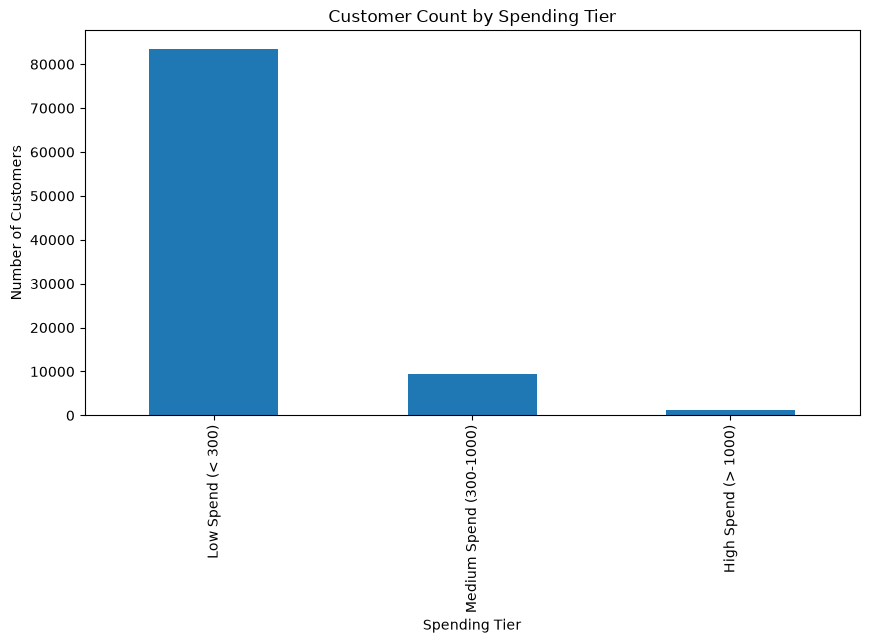

In [25]:
customer_spend['spend_tier'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Customer Count by Spending Tier')
plt.ylabel('Number of Customers')
plt.xlabel('Spending Tier')
plt.show()